### Q3 — Write your own function to equalize the histogram of an image, and apply it to the runway image

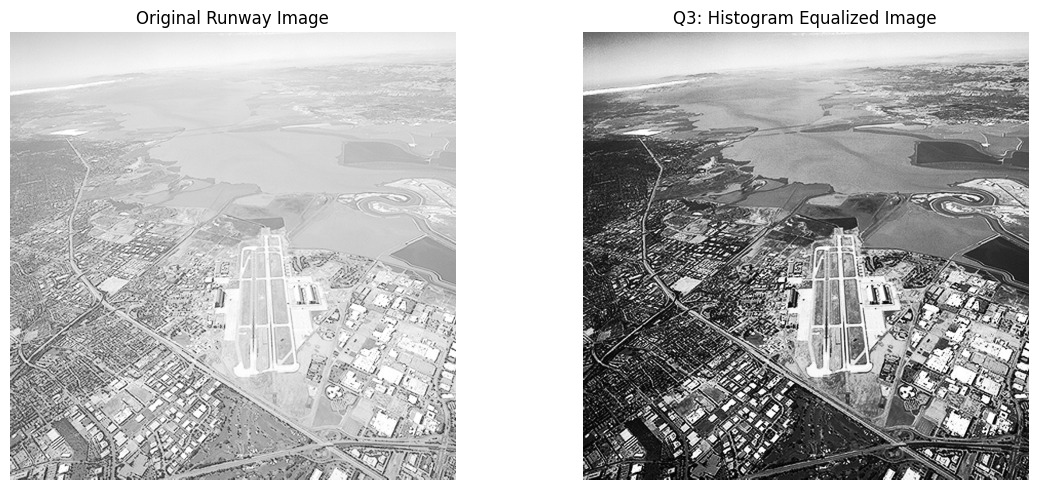

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load runway image as grayscale
img = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)

def my_hist_equalization(image):
    # Step 1: compute histogram
    hist = np.zeros(256, dtype=int)
    for pixel in image.ravel():
        hist[pixel] += 1

    # Step 2: normalize histogram
    total_pixels = image.size
    pdf = hist / total_pixels

    # Step 3: compute cumulative distribution function (CDF)
    cdf = np.cumsum(pdf)

    # Step 4: build transformation table
    transform = np.floor(255 * cdf).astype(np.uint8)

    # Step 5: map original intensities to equalized intensities
    equalized = transform[image]

    return equalized, hist, cdf, transform

# Apply manual histogram equalization
eq_img, hist_orig, cdf_orig, transform = my_hist_equalization(img)

# Display original and equalized images
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Runway Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(eq_img, cmap='gray')
plt.title('Q3: Histogram Equalized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### Histogram comparison

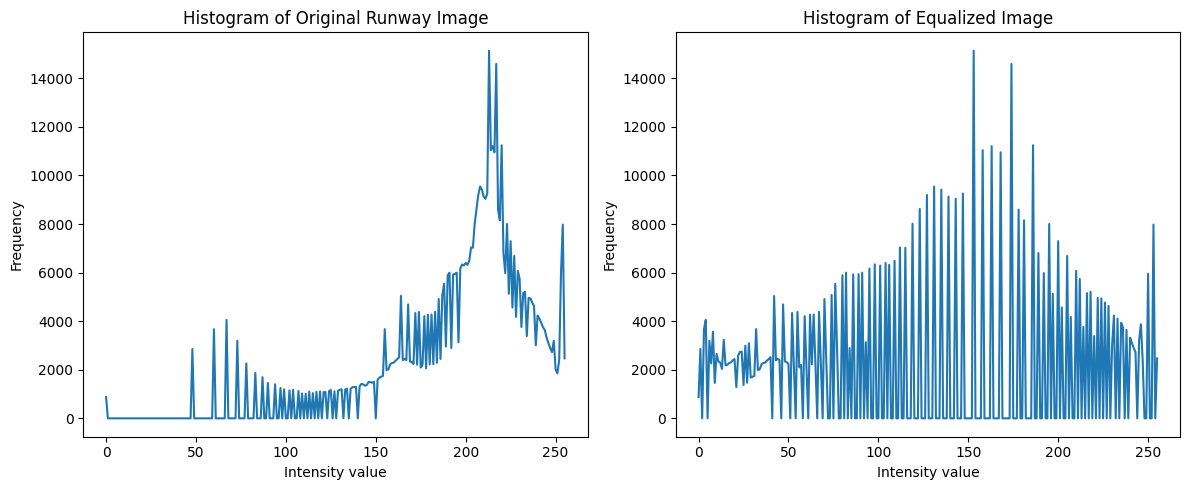

In [4]:
hist_eq, _ = np.histogram(eq_img.flatten(), bins=256, range=[0,256])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist_orig)
plt.title('Histogram of Original Runway Image')
plt.xlabel('Intensity value')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.plot(hist_eq)
plt.title('Histogram of Equalized Image')
plt.xlabel('Intensity value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### CDF visualization

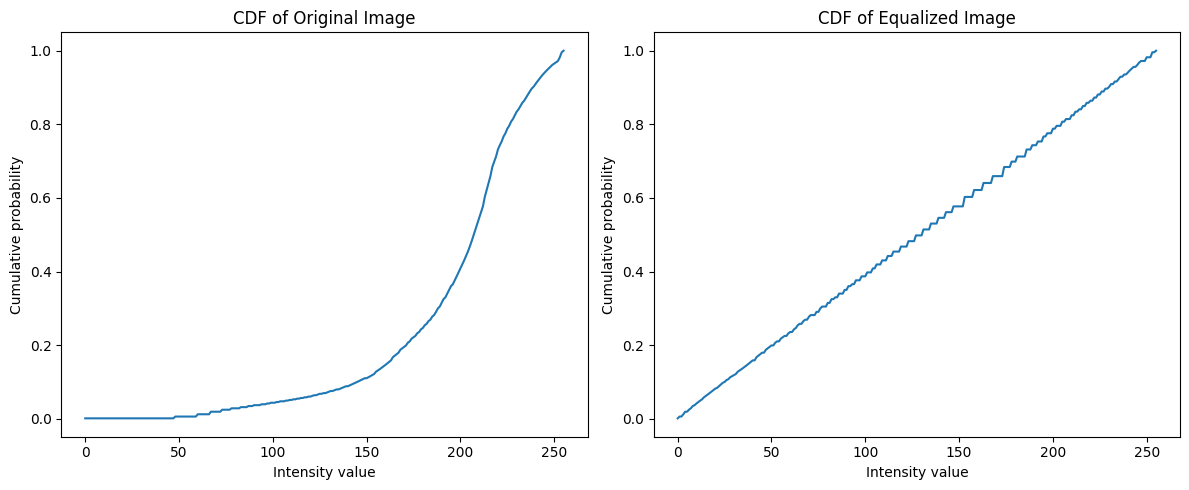

In [5]:
cdf_eq = np.cumsum(hist_eq / eq_img.size)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(cdf_orig)
plt.title('CDF of Original Image')
plt.xlabel('Intensity value')
plt.ylabel('Cumulative probability')

plt.subplot(1,2,2)
plt.plot(cdf_eq)
plt.title('CDF of Equalized Image')
plt.xlabel('Intensity value')
plt.ylabel('Cumulative probability')

plt.tight_layout()
plt.show()

### Full comparison figure

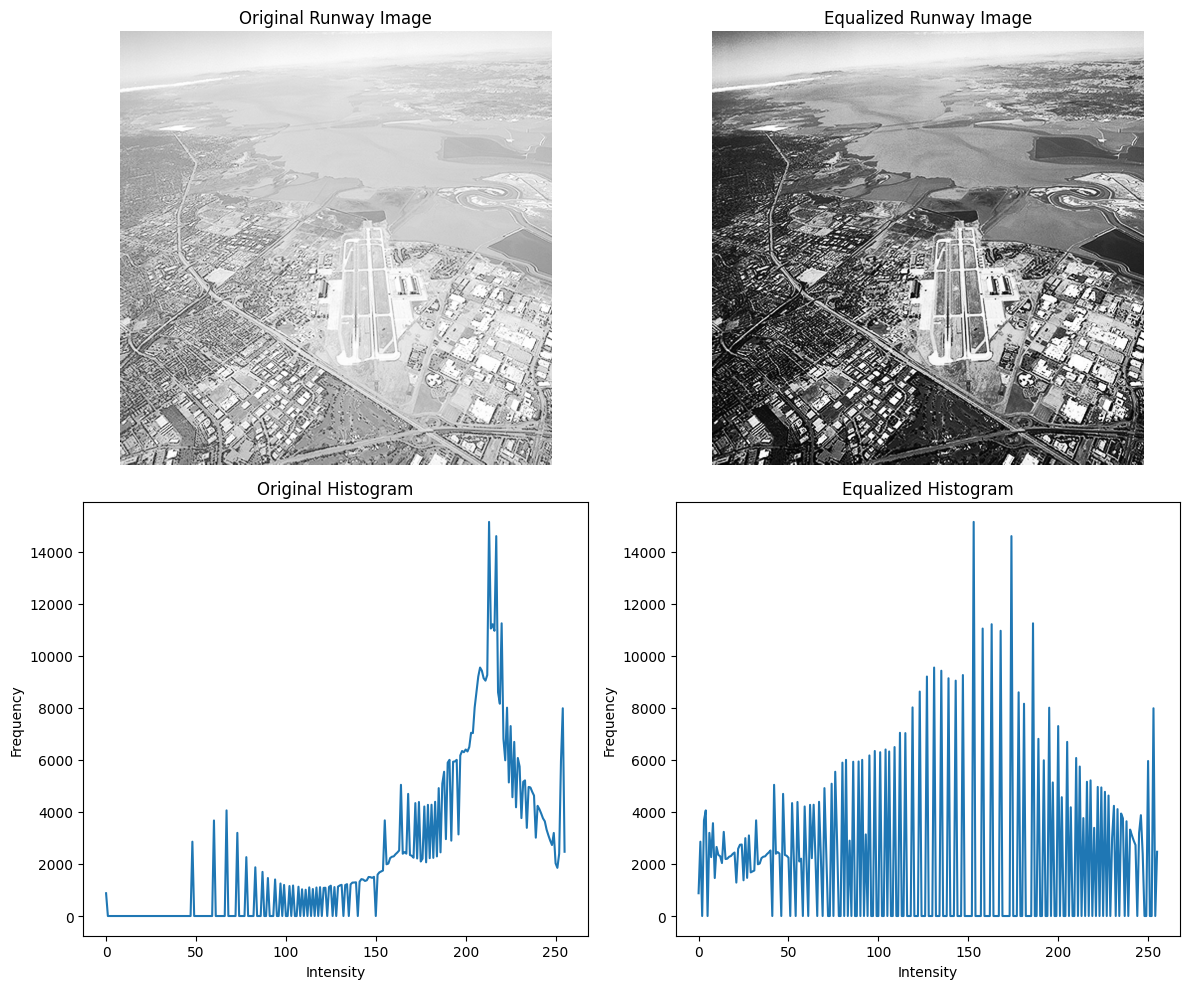

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title('Original Runway Image')
axes[0,0].axis('off')

axes[0,1].imshow(eq_img, cmap='gray')
axes[0,1].set_title('Equalized Runway Image')
axes[0,1].axis('off')

axes[1,0].plot(hist_orig)
axes[1,0].set_title('Original Histogram')
axes[1,0].set_xlabel('Intensity')
axes[1,0].set_ylabel('Frequency')

axes[1,1].plot(hist_eq)
axes[1,1].set_title('Equalized Histogram')
axes[1,1].set_xlabel('Intensity')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### validation using OpenCV

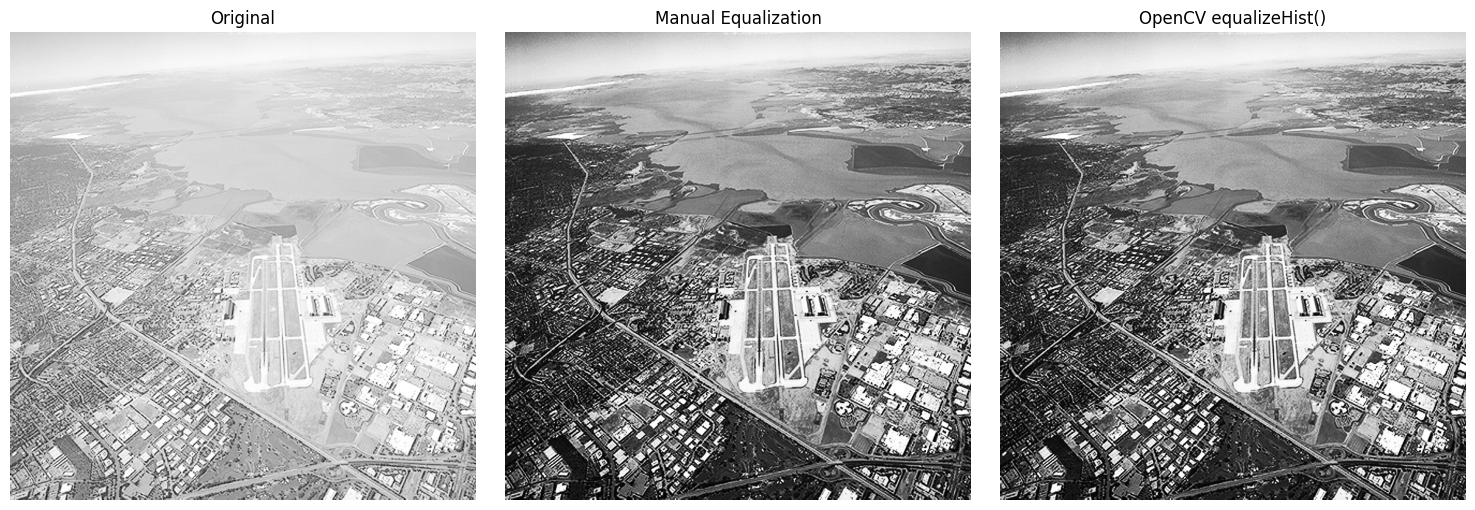

In [7]:
eq_cv = cv.equalizeHist(img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(eq_img, cmap='gray')
plt.title('Manual Equalization')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(eq_cv, cmap='gray')
plt.title('OpenCV equalizeHist()')
plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
difference = np.abs(eq_img.astype(np.int16) - eq_cv.astype(np.int16))
print("Maximum absolute difference:", difference.max())
print("Mean absolute difference:", difference.mean())

Maximum absolute difference: 1
Mean absolute difference: 0.37949973227262296


#### A manual histogram equalization function was implemented using the image histogram and its cumulative distribution function. The method was applied to the runway image, which originally had low contrast. After equalization, the grayscale levels were redistributed over a wider range, improving the visibility of important features such as the runway and surrounding urban details.